In [50]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
import pymc as pm
from sklearn.metrics import precision_recall_curve


In [51]:
df = pd.read_csv("grad_test.csv")

In [52]:
df.reset_index(drop=True)
df = df.set_index('loan_id')

In [53]:
# Feature selection preventing data leakage
df_model = df[[
"customer_id",
"policy_version",
"annual_income",
"loan_amount",
"credit_score",
"employment_status",
"channel",
"broker_id",
"debt_to_income",
"previous_loan_count",
"previous_defaults",
"thin_file_flag",
"approved_limit",
"underwriter_score",
"defaulted"]].copy()

# ____Handling missing data____

In [54]:
pd.isna(df_model).sum()

customer_id               0
policy_version            0
annual_income          1163
loan_amount               0
credit_score            690
employment_status         0
channel                   0
broker_id                 0
debt_to_income            0
previous_loan_count       0
previous_defaults         0
thin_file_flag            0
approved_limit            0
underwriter_score         0
defaulted                 0
dtype: int64

In [55]:
# All the missing credit_score data are explained by thin_file_flag
pd.crosstab(
    df_model["credit_score"].isna(),
    df_model["thin_file_flag"]
)

thin_file_flag,0,1
credit_score,,
False,8785,525
True,0,690


In [56]:
# Create a binary vairable indicating the missingness of annumal_income, and credit_score
df_model['annual_income_missing'] = df_model["annual_income"].isna().astype(int) 
# Fill in NAs with the median of the variable
df_model["annual_income"] = df_model["annual_income"].fillna(df_model["annual_income"].median())
df_model['credit_score'] = df_model['credit_score'].fillna(df_model['credit_score'].median())


In [57]:
# 'Broker_id' missingness is fully explained by 'channel' variable
pd.crosstab(
    df_model['broker_id'] == 'none',
    df_model['channel']
)

channel,affiliate,broker,direct,paid_search
broker_id,,,,
False,0,2778,0,0
True,1752,0,4469,1001


# ___Correlation check___

In [58]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, L0006252 to L0007270
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            10000 non-null  object 
 1   policy_version         10000 non-null  object 
 2   annual_income          10000 non-null  float64
 3   loan_amount            10000 non-null  int64  
 4   credit_score           10000 non-null  float64
 5   employment_status      10000 non-null  object 
 6   channel                10000 non-null  object 
 7   broker_id              10000 non-null  object 
 8   debt_to_income         10000 non-null  float64
 9   previous_loan_count    10000 non-null  int64  
 10  previous_defaults      10000 non-null  int64  
 11  thin_file_flag         10000 non-null  int64  
 12  approved_limit         10000 non-null  int64  
 13  underwriter_score      10000 non-null  int64  
 14  defaulted              10000 non-null  int64  
 1

<Axes: >

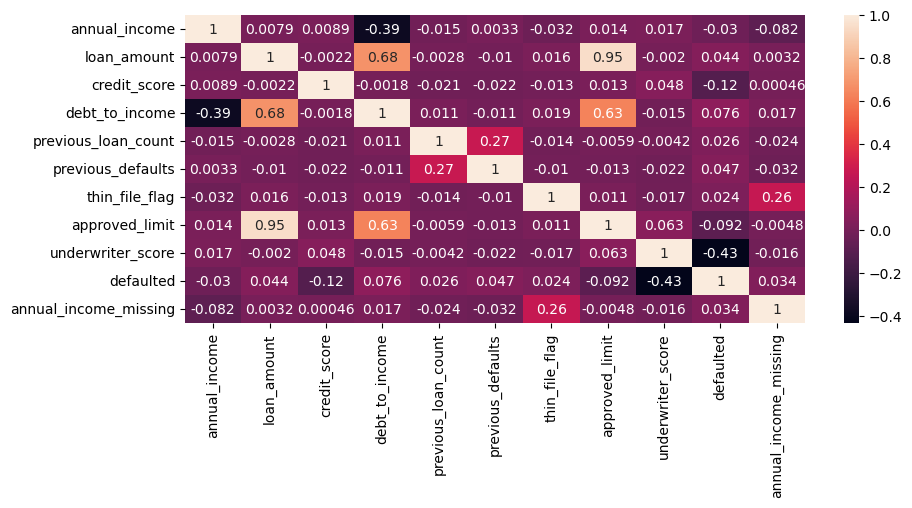

In [59]:
df_numeric = df_model.select_dtypes(include='number')
corr_matrix = df_numeric.corr()

plt.figure(figsize=(10,4))
sns.heatmap(corr_matrix, annot = True)

In [60]:
# Baseline model for feature selection - it would be worht checking the conceptual meaning of 'underwriter_score'
# For now, the variable needs to be removed to prevent possible leakage
X_baseline = df_model[['underwriter_score']]
y_baseline = df_model['defaulted']

X_train, X_test, y_train, y_test = train_test_split(
    X_baseline, y_baseline, test_size=0.33, random_state=42)

baseline_model = LogisticRegression()
baseline_model.fit(X_train, y_train)
y_prob = baseline_model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.9416171591389195


In [61]:
# Feature engineering
df_model["dti_income_ratio"] = df_model["debt_to_income"] / (df_model["annual_income"] + 1)

df_model["loan_to_income"] = df_model["loan_amount"] / (df_model["annual_income"] + 1)

df_model["default_rate_history"] = (
    df_model["previous_defaults"] / (df_model["previous_loan_count"] + 1)
)

df_model["thin_file_ratio"] = df_model["thin_file_flag"] * (df_model["previous_loan_count"] == 0).astype(int)

df_model["log_income"] = np.log1p(df_model["annual_income"])

df_model["score_dti_interaction"] = (
    df_model["credit_score"] * df_model["debt_to_income"]
)

df_model["credit_buffer"] = (
    df_model["approved_limit"] - df_model["loan_amount"]
)

### ___Train-test split___

In [62]:
df_dummies = pd.get_dummies(df_model[['policy_version', 'employment_status', 'channel']], drop_first=False, dtype=float)

In [63]:
df_model = pd.concat([df_model, df_dummies], axis=1)

In [64]:
# Remove covariates causing multicolllinearity, unethical decision making and data leakage
y = df_model['defaulted']
X = df_model.drop(columns=['defaulted', 'customer_id', 'broker_id', 'policy_version', 'employment_status', 'channel', 'underwriter_score']).copy()


In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

Logistic Regression

In [66]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg_model = LogisticRegression(class_weight="balanced") # penalise mistakes in the minority class more heavily
logreg_model.fit(X_train_scaled, y_train)



LogisticRegression(class_weight='balanced')

In [67]:
y_prob = logreg_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob > 0.3).astype(int)
print("PR-AUC:", average_precision_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

PR-AUC: 0.7698956452414691
              precision    recall  f1-score   support

           0       1.00      0.79      0.88      3141
           1       0.19      0.97      0.31       159

    accuracy                           0.79      3300
   macro avg       0.59      0.88      0.60      3300
weighted avg       0.96      0.79      0.85      3300



In [68]:
# In credit risk scoring, bigger importance is associated with the recall. 
# Therefore, it might be worth adjusting the classification threshold, so that more actual fraudsters are detected. 

In [69]:
# Single-feature ROC-AUC 

for col in X_train.columns:
    auc = roc_auc_score(y_test, X_test[col])
    print(col, auc)

annual_income 0.463719842456935
loan_amount 0.5813385153548424
credit_score 0.3622399227902823
debt_to_income 0.5778784948109703
previous_loan_count 0.5493213113638047
previous_defaults 0.5251151838436263
thin_file_flag 0.5201954671328083
approved_limit 0.36691735796996106
annual_income_missing 0.5200362821598697
dti_income_ratio 0.5693215516430092
loan_to_income 0.586794855622233
default_rate_history 0.5251692466646243
thin_file_ratio 0.511272098178083
log_income 0.463719842456935
score_dti_interaction 0.5501442676389965
credit_buffer 0.04402415606935258
policy_version_v1_old_policy 0.48385624095198626
policy_version_v2_tighter_policy 0.5161437590480138
employment_status_employed 0.45624816036234106
employment_status_retired 0.48671255999471386
employment_status_self_employed 0.5364413448427072
employment_status_student 0.49320310200452927
employment_status_unemployed 0.5273948327957086
channel_affiliate 0.47717347557862233
channel_broker 0.5390003183699459
channel_direct 0.4903017306

In [70]:
logreg_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced')

In [71]:
# Single-feature ROC-AUC analysis 

result = permutation_importance(
    logreg_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
}).sort_values("importance", ascending=False)

print(importance_df)

                             feature  importance       std
15                     credit_buffer    0.392054  0.023828
7                     approved_limit    0.041786  0.009813
14             score_dti_interaction    0.014396  0.002857
3                     debt_to_income    0.014354  0.005083
2                       credit_score    0.007190  0.002706
10                    loan_to_income    0.006691  0.002101
1                        loan_amount    0.006619  0.004366
13                        log_income    0.003901  0.001092
11              default_rate_history    0.003583  0.001594
5                  previous_defaults    0.002530  0.001057
0                      annual_income    0.000975  0.000514
9                   dti_income_ratio    0.000569  0.001034
4                previous_loan_count    0.000520  0.000344
24                    channel_broker    0.000451  0.000708
25                    channel_direct    0.000354  0.000228
23                 channel_affiliate    0.000252  0.0004

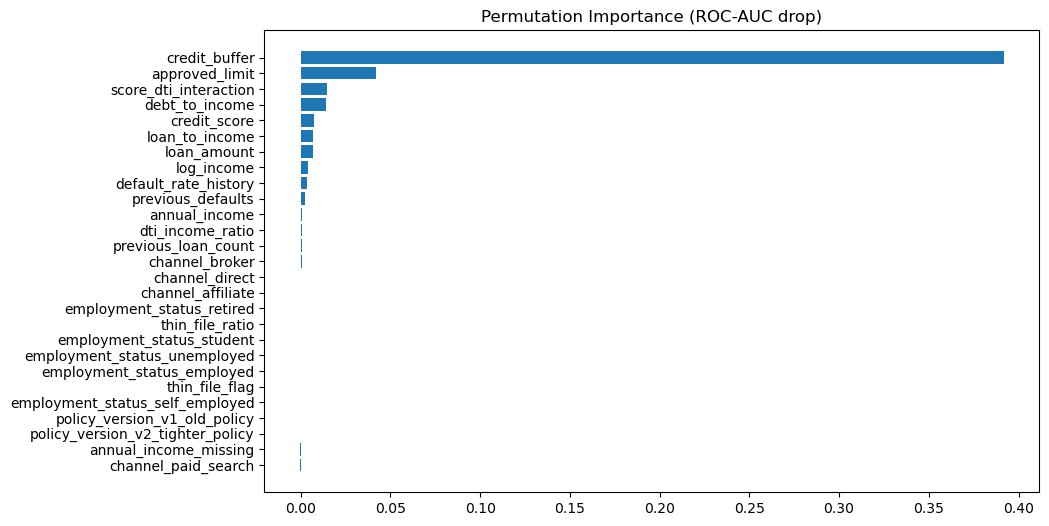

In [72]:
# Permutation importance

plt.figure(figsize=(10,6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Permutation Importance (ROC-AUC drop)")
plt.show()

Single-feature ROC-AUC analysis shows no evidence of strong individual leakage signals. However, permutation importance reveals that model performance is primarily driven by approved_limit and loan_amount, while most other features contribute negligible predictive value. This suggests that the model is largely capturing structural relationships in loan sizing rather than distributed borrower-level risk signals. 
Further investigation is needed to assess whether approved_limit encodes downstream underwriting policy.

The logistic regression model achieves a high ROC-AUC of 0.97, suggesting that predictive signal is distributed across multiple weak  and a couple of dominating features and their interactions. Further validation using time-based splits or out-of-sample testing would be needed to confirm robustness and rule out structural or segment-based separability.

In [73]:
# Remove 'approved_limit'
y = df_model['defaulted']
X_train = X_train.drop(columns=['approved_limit']).copy()
X_test = X_test.drop(columns=['approved_limit']).copy()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg_model = LogisticRegression(class_weight="balanced") # penalise mistakes in the minority class more heavily
logreg_model.fit(X_train_scaled, y_train)

y_pred = logreg_model.predict(X_test_scaled)
y_prob = logreg_model.predict_proba(X_test_scaled)[:,1] # risk scores


In [74]:
y = (y_prob > 0.6).astype(int)

print("PR-AUC:", average_precision_score(y_test, y_prob))
print(classification_report(y_test, y))

PR-AUC: 0.7691395299735585
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      3141
           1       0.42      0.86      0.56       159

    accuracy                           0.94      3300
   macro avg       0.70      0.90      0.76      3300
weighted avg       0.96      0.94      0.95      3300



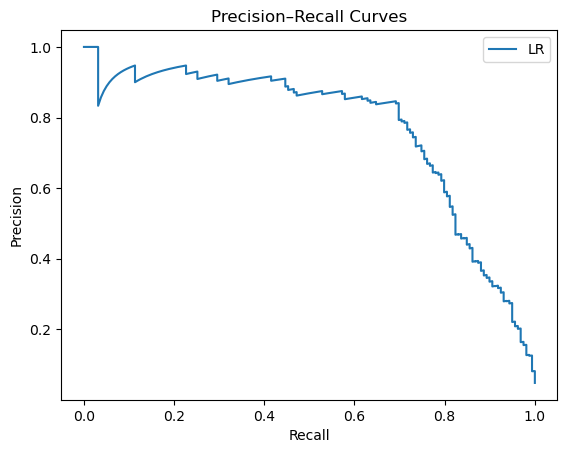

In [75]:
plt.figure()


p, r, _ = precision_recall_curve(y_test, y_prob)
plt.plot(r, p, label="LR")


plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title("Precision–Recall Curves")
plt.show()

In [76]:
# Class imbalance
print(df['defaulted'].value_counts())
print(df['defaulted'].value_counts(normalize = True) * 100)

defaulted
0    9499
1     501
Name: count, dtype: int64
defaulted
0    94.99
1     5.01
Name: proportion, dtype: float64


Removing approved_limit resulted in a significant drop in RP-AUC from 0.77 to 0.11, indicating that the original model heavily relied on a variable likely derived from underwriting policy rather than pure borrower characteristics. This suggests that the initial performance was inflated by structural signals embedded in loan assignment decisions, and that the remaining feature set reflects a more realistic measure of predictive power.

GradientBoostingClassifier

In [77]:
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# Train model
gbm = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbm.fit(X_train_scaled, y_train, sample_weight=sample_weights)

# Predict
y_pred = gbm.predict(X_test_scaled)
y_prob = gbm.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob > 0.4).astype(int)
# Evaluate
print("PR AUC:", average_precision_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

PR AUC: 0.7852264781821248
              precision    recall  f1-score   support

           0       0.99      0.91      0.95      3141
           1       0.34      0.90      0.49       159

    accuracy                           0.91      3300
   macro avg       0.67      0.90      0.72      3300
weighted avg       0.96      0.91      0.93      3300



XGB Classifier

In [78]:
# Build classifier

xgb = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    reg_alpha=0.5,
    reg_lambda=1.0,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric="aucpr",
    random_state=42
)

In [79]:
xgb.fit(X_train_scaled, y_train)
# Predict
y_pred = xgb.predict(X_test_scaled)
y_prob = xgb.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob > 0.4).astype(int)
# Evaluate
print("PR AUC:", average_precision_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

PR AUC: 0.7825998269432897
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      3141
           1       0.41      0.87      0.56       159

    accuracy                           0.93      3300
   macro avg       0.70      0.91      0.76      3300
weighted avg       0.97      0.93      0.95      3300



Hierachical Bayesian Model

In [80]:
# Reconstruct channel varuiable
channel_cols = [
    "channel_affiliate",
    "channel_broker",
    "channel_direct",
    "channel_paid_search"
]

X_train["channel"] = (
    X_train[channel_cols]
    .idxmax(axis=1)
    .str.replace("channel_", "")
)

X_test["channel"] = (
    X_test[channel_cols]
    .idxmax(axis=1)
    .str.replace("channel_", "")
)

In [81]:
channel_idx = pd.factorize(X_train["channel"])[0]
channel_idx = pd.factorize(X_test["channel"])[0]

In [82]:
X_train = X_train.drop(columns = ['channel_affiliate', 'channel_broker', 'channel_direct',
       'channel_paid_search']).copy()

X_test = X_test.drop(columns = ['channel_affiliate', 'channel_broker', 'channel_direct',
       'channel_paid_search']).copy()

In [83]:

n_channels = len(np.unique(channel_idx))

In [84]:


# -----------------------------
# 1. SCALE NUMERIC FEATURES
# -----------------------------


# Split
y = df_model["defaulted"]

# Scale numeric variables using TRAIN ONLY
cols = [
    "annual_income",
    "loan_amount",
    "credit_score",
    "debt_to_income",
    "previous_loan_count",
    "previous_defaults",
    'dti_income_ratio', 
    'loan_to_income',
    'default_rate_history', 
    'thin_file_ratio', 
    'log_income', 
    'score_dti_interaction', 
    'credit_buffer'
]

scaler = StandardScaler()

X_train_scaled_Bayes = X_train.copy()
X_test_scaled_Bayes = X_test.copy()

X_train_scaled_Bayes[cols] = scaler.fit_transform(X_train[cols])
X_test_scaled_Bayes[cols] = scaler.transform(X_test[cols])

# Channel encoding
channel_categories = X_train_scaled_Bayes["channel"].unique()

channel_map = {
    c: i for i, c in enumerate(channel_categories)
}

train_channel_idx = X_train_scaled_Bayes["channel"].map(channel_map).values
test_channel_idx = X_test_scaled_Bayes["channel"].map(channel_map).values

n_channels = len(channel_map)

In [85]:
with pm.Model() as hbm:

    mu_alpha = pm.Normal("mu_alpha", 0, 0.5)
    sigma_alpha = pm.HalfNormal("sigma_alpha", 0.5)

    alpha = pm.Normal(
        "alpha",
        mu=mu_alpha,
        sigma=sigma_alpha,
        shape=n_channels
    )

    beta_income = pm.Normal("beta_income", 0, 0.5)
    beta_score = pm.Normal("beta_score", 0, 0.5)
    beta_dti = pm.Normal("beta_dti", 0, 0.5)
    beta_prev_def = pm.Normal("beta_prev_def", 0, 0.5)
    beta_dti_income_ratio = pm.Normal("beta_dti_income_ratio", 0, 0.5)
    beta_loan_income = pm.Normal("beta_loan_income", 0, 0.5)
    beta_default_rate_history = pm.Normal("beta_default_rate_history", 0, 0.5)
    beta_thin_file_ratio = pm.Normal("beta_thin_file_ratio", 0, 0.5)
    beta_log_income = pm.Normal("beta_log_income", 0, 0.5)
    beta_score_dti_interaction = pm.Normal("beta_score_dti_interaction", 0, 0.5)
    beta_credit_buffer = pm.Normal("beta_credit_buffer", 0, 0.5)

    logit_p = (
        alpha[train_channel_idx]
        + beta_income * X_train_scaled_Bayes["annual_income"].values
        + beta_score * X_train_scaled_Bayes["credit_score"].values
        + beta_dti * X_train_scaled_Bayes["debt_to_income"].values
        + beta_prev_def * X_train_scaled_Bayes["previous_defaults"].values
        + beta_dti_income_ratio * X_train_scaled_Bayes["dti_income_ratio"].values
        + beta_loan_income * X_train_scaled_Bayes["loan_to_income"].values
        + beta_default_rate_history * X_train_scaled_Bayes["default_rate_history"].values
        + beta_thin_file_ratio * X_train_scaled_Bayes["thin_file_ratio"].values
        + beta_log_income * X_train_scaled_Bayes["log_income"].values
        + beta_score_dti_interaction * X_train_scaled_Bayes["score_dti_interaction"].values
        + beta_credit_buffer * X_train_scaled_Bayes["credit_buffer"].values
    )

    p = pm.math.sigmoid(logit_p)

    y_obs = pm.Bernoulli(
        "y_obs",
        p=p,
        observed=y_train.values
    )

    trace = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        target_accept=0.95,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, alpha, beta_income, beta_score, beta_dti, beta_prev_def, beta_dti_income_ratio, beta_loan_income, beta_default_rate_history, beta_thin_file_ratio, beta_log_income, beta_score_dti_interaction, beta_credit_buffer]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 102 seconds.


In [86]:
# =====================================
# Extract posterior mean coefficients
# =====================================

alpha_mean = (
    trace.posterior["alpha"]
    .mean(dim=("chain", "draw"))
    .values
)

beta_income = float(
    trace.posterior["beta_income"]
    .mean(dim=("chain", "draw"))
    .values
)

beta_score = float(
    trace.posterior["beta_score"]
    .mean(dim=("chain", "draw"))
    .values
)

beta_dti = float(
    trace.posterior["beta_dti"]
    .mean(dim=("chain", "draw"))
    .values
)

beta_prev_def = float(
    trace.posterior["beta_prev_def"]
    .mean(dim=("chain", "draw"))
    .values
)

beta_dti_income_ratio = float(trace.posterior["beta_dti_income_ratio"].mean(("chain", "draw")).values)
beta_loan_income = float(trace.posterior["beta_loan_income"].mean(("chain", "draw")).values)
beta_default_rate_history = float(trace.posterior["beta_default_rate_history"].mean(("chain", "draw")).values)
beta_thin_file_ratio = float(trace.posterior["beta_thin_file_ratio"].mean(("chain", "draw")).values)
beta_log_income = float(trace.posterior["beta_log_income"].mean(("chain", "draw")).values)
beta_score_dti_interaction = float(trace.posterior["beta_score_dti_interaction"].mean(("chain", "draw")).values)
beta_credit_buffer = float(trace.posterior["beta_credit_buffer"].mean(("chain", "draw")).values)



# =====================================
# Compute test-set probabilities
# =====================================

logit_test = (
    alpha_mean[test_channel_idx]
    + beta_income * X_test_scaled_Bayes["annual_income"].values
    + beta_score * X_test_scaled_Bayes["credit_score"].values
    + beta_dti * X_test_scaled_Bayes["debt_to_income"].values
    + beta_prev_def * X_test_scaled_Bayes["previous_defaults"].values
    + beta_dti_income_ratio * X_test_scaled_Bayes["dti_income_ratio"].values
    + beta_loan_income * X_test_scaled_Bayes["loan_to_income"].values
    + beta_default_rate_history * X_test_scaled_Bayes["default_rate_history"].values
    + beta_thin_file_ratio * X_test_scaled_Bayes["thin_file_ratio"].values
    + beta_log_income * X_test_scaled_Bayes["log_income"].values
    + beta_score_dti_interaction * X_test_scaled_Bayes["score_dti_interaction"].values
    + beta_credit_buffer * X_test_scaled_Bayes["credit_buffer"].values
)

bayes_pd_test = 1 / (1 + np.exp(-logit_test))

# =====================================
# Evaluate
# =====================================


print("ROC-AUC:", roc_auc_score(y_test, bayes_pd_test))
print("PR-AUC:", average_precision_score(y_test, bayes_pd_test))

ROC-AUC: 0.9674041235916135
PR-AUC: 0.7211417344121023


In [87]:


threshold = 0.1
y_pred = (bayes_pd_test >= threshold).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97      3141
           1       0.41      0.84      0.55       159

    accuracy                           0.94      3300
   macro avg       0.70      0.89      0.76      3300
weighted avg       0.96      0.94      0.95      3300



In [88]:
# Channel-level risk on the test set 
test_results = X_test.copy()

test_results["defaulted"] = y_test.values
test_results["bayesian_pd"] = bayes_pd_test

test_results.groupby("channel")["bayesian_pd"].mean()

channel
affiliate      0.046457
broker         0.074130
direct         0.049980
paid_search    0.037360
Name: bayesian_pd, dtype: float64

In [89]:
broker_stats = (
    df_model.groupby("broker_id")
    .agg(
        loans=("defaulted", "count"),
        default_rate=("defaulted", "mean")
    )
    .query("loans >= 30")
    .sort_values("default_rate", ascending=False)
)

broker_stats.head(20)

,loans,default_rate
broker_id,,
none,7222,0.044724


Broker-level hierarchical effects were considered; however, the broker distribution was highly sparse, with over 72% of observations belonging to a non-broker category and most individual brokers contributing fewer than 20 loans. Consequently, broker-level estimates would be heavily driven by hierarchical shrinkage and unlikely to provide reliable risk differentiation. Channel-level effects were therefore used as the primary grouping structure.

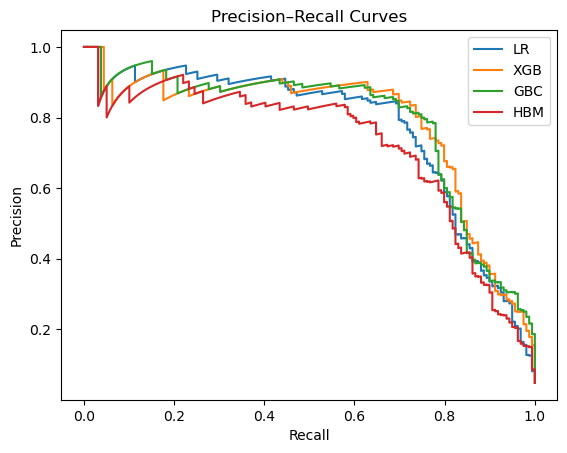

In [90]:
# Precision–Recall curves
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

plt.figure()

# Logistic Regression
p_lr, r_lr, _ = precision_recall_curve(
    y_test,
    logreg_model.predict_proba(X_test_scaled)[:, 1]
)
plt.plot(r_lr, p_lr, label="LR")

# XGBoost
p_xgb, r_xgb, _ = precision_recall_curve(
    y_test,
    xgb.predict_proba(X_test_scaled)[:, 1]
)
plt.plot(r_xgb, p_xgb, label="XGB")

# Gradient Boosting
p_gbc, r_gbc, _ = precision_recall_curve(
    y_test,
    gbm.predict_proba(X_test_scaled)[:, 1]
)
plt.plot(r_gbc, p_gbc, label="GBC")

# Bayesian model (separate variable, no model logic needed)
p_hbm, r_hbm, _ = precision_recall_curve(
    y_test,
    bayes_pd_test
)
plt.plot(r_hbm, p_hbm, label="HBM")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title("Precision–Recall Curves")
plt.show()